# قصة الأسعار: خمس عشرة سنة من أسعار الغذاء في مصر

هذا الدفتر تحليل استكشافي كامل باللغة العربية لبيانات حقيقية من السوق المصري،
باستخدام مكتبة [dextra](https://pypi.org/project/pydextra/) المبنية على قاعدة
واحدة: **كل قرار آلي يُفصَح عنه، وأنت تبقى صاحب القرار.**

لماذا بالعربية؟ لأن المحتوى العربي الجاد في تحليل البيانات نادر، ولأن قارئ
العربية يستحق أن يرى التحليل الصادق على بيانات من واقعه — أسعار الدقيق
والسكر والطماطم في السوق المصري — لا على بيانات أزهار أيريس.

رحلة الدفتر:

1. **تحميل مُفصَح** — ماذا قرر `load` نيابة عنا، وكيف نراجعه.
2. **جرد الجودة** — الفقدان والتكرار وقواعد السلامة.
3. **فخّان بنيويان** — حُبيبية مختلطة في عمود واحد، وسلسلة تنقطع عام 2022
   لتظهر بديلتها باسم آخر: هل نوصلهما؟ **الاختبار الإحصائي يقرر، لا المزاج.**
4. **قصة الجنيه** — سعر الصرف الضمني من 5.7 إلى ما فوق 50 جنيهاً للدولار.
5. **التضخم بالرقم القياسي** — بالجنيه ثم بالدولار، والفرق بينهما هو القصة.
6. **سلاسل زمنية وشواذ صادقة** — اتجاه أم موسمية؟ ومن يصرخ في البيانات فعلاً؟
7. **تقرير HTML شامل** بسطر واحد، ثم القرارات الموثقة.

## بطاقة البيانات والإسناد

| البند | القيمة |
|---|---|
| المصدر | برنامج الأغذية العالمي (WFP) — قاعدة أسعار الغذاء |
| المنصة | [Humanitarian Data Exchange (HDX)](https://data.humdata.org/dataset/wfp-food-prices-for-egypt) |
| الترخيص | **CC BY-IGO** — إسناد للمنظمات الحكومية الدولية |
| المصادر الأولية | CAPMAS (الجهاز المركزي للتعبئة والإحصاء) وIDSC (مركز معلومات مجلس الوزراء) |
| الملف الرئيس | `wfp_food_prices_egy.csv` — أسعار تجزئة شهرية |
| ملف مرافق | `wfp_markets_egy.csv` — دليل 68 سوقاً بإحداثياتها |
| المدى الزمني | أغسطس 2010 حتى مارس 2026 |

**الإسناد**: بيانات أسعار الغذاء من برنامج الأغذية العالمي عبر منصة HDX،
بترخيص CC BY-IGO. التحليل والآراء هنا مسؤولية كاتب الدفتر لا المصدر.

## قاموس المصطلحات

| المصطلح | بالإنجليزية | المعنى في هذا الدفتر |
|---|---|---|
| تحليل استكشافي | EDA | فهم البيانات قبل أي نمذجة: أشكالها وثقوبها وقصصها |
| قسر الأنواع | Type coercion | تحويل عمود نصي إلى رقم/تاريخ — مفيد إن أُفصح عنه، مدمر إن تسلل |
| حُبيبية | Granularity | مستوى تفصيل الصف: وطني؟ سوق واحد؟ خلطهما يفسد المتوسطات |
| فقدان بنيوي | Structural missingness | فراغ موجود **بالتعريف** لا بالصدفة — تعويضه خطأ منطقي |
| اختبار ت المزدوج | Paired t-test | مقارنة قياسين لنفس الوحدات (نفس السلعة، نفس الشهر) |
| سكون السلسلة | Stationarity | ثبات خصائص السلسلة عبر الزمن؛ ADF وKPSS اختباراه |
| تفكيك السلسلة | Decomposition | فصل السلسلة إلى اتجاه + موسمية + بواقٍ |
| رقم قياسي | Index (base=100) | تحويل الأسعار لنِسَب من فترة أساس — شرط المقارنة العادلة |
| سعر الصرف الضمني | Implied exchange rate | ناتج قسمة السعر بالجنيه على السعر بالدولار في نفس الصف |
| قيمة شاذة | Outlier | ما يخرج عن النمط — **التحقق قبل الحذف** دائماً |
| المدى الربيعي | IQR | قاعدة ميكانيكية لرصد الشواذ؛ سنرى حدودها مع الصدمات |
| إفصاح | Disclosure | إعلان كل قرار تحويلي؛ جوهر فلسفة dextra |
| تسريب | Leakage | وصول معلومات التقييم إلى خطوات التدريب — موضوع الدفتر 2 كاملاً |

In [1]:
%pip install -q "pydextra[io,ts]"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import dextra as dx

print("dextra", dx.__version__, "| pandas", pd.__version__)

dextra 0.5.1 | pandas 3.0.3


## التنزيل — مرة واحدة ثم كاش

الخلية التالية تنزّل الملفين من روابط HDX الرسمية إن لم يكونا موجودين في
`data/`، ولا تعيد التنزيل في التشغيلات اللاحقة.

In [3]:
import urllib.request
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
HDX = "https://data.humdata.org/dataset/230e991f-3438-4763-8044-e424b5a67bec/resource"
FILES = {
    "wfp_food_prices_egy.csv": f"{HDX}/561cea27-29af-40b8-bf3f-633c734cecb2/download/wfp_food_prices_egy.csv",
    "wfp_markets_egy.csv":     f"{HDX}/e20b5388-eced-4999-875c-a30886fa8428/download/wfp_markets_egy.csv",
}
for name, url in FILES.items():
    p = DATA_DIR / name
    if not p.exists():
        urllib.request.urlretrieve(url, p)
    print(f"{name}: {p.stat().st_size/1e3:.0f} KB")
print("Data: WFP Food Prices via HDX -- license CC BY-IGO")

wfp_food_prices_egy.csv: 389 KB
wfp_markets_egy.csv: 3 KB
Data: WFP Food Prices via HDX -- license CC BY-IGO


## التحميل المُفصَح

`dx.load` لا يكتفي بالقراءة: يقرر الترميز والفاصل وأنواع الأعمدة، ثم **يطبع
كل قرار اتخذه** في تقرير واحد. اقرأ التقرير قبل أي سطر تحليل.

In [4]:
prices = dx.load(str(DATA_DIR / "wfp_food_prices_egy.csv"))

source=wfp_food_prices_egy.csv | encoding=utf-8 | sep=',' | header=row 0 | 3,490x16
      column          dtype  parsed_%  null_%  n_distinct problem   action confidence
        date datetime64[us]  100.0000  0.0000         186                   confirmed
      admin1         object  100.0000 74.7300           1         category  confirmed
      admin2         object  100.0000 74.7300           1         category  confirmed
      market         object  100.0000  0.0000           2         category  confirmed
   market_id          int64  100.0000  0.0000           2                   confirmed
    latitude        float64  100.0000 74.7300           1                   confirmed
   longitude        float64  100.0000 74.7300           1                   confirmed
    category         object  100.0000  0.0000           7         category  confirmed
   commodity         object  100.0000  0.0000          31         category  confirmed
commodity_id          int64  100.0000  0.0000          3

### قراءة التقرير

ثلاث ملاحظات تستحق التوقف:

- **`date` صار `datetime` تلقائياً** — قسر مُفصَح عنه في العمود الأول من
  التقرير، لا مفاجأة مدفونة.
- **أربعة أعمدة جغرافية ناقصة بنسبة ~74.7%** (`admin1`، `admin2`،
  `latitude`، `longitude`) — التقرير يكشفها فوراً. ليست أخطاء إدخال؛ سنكتشف
  في الجرد أنها **فقدان بنيوي** له معنى.
- **المعرّفات سلمت هنا** — `market_id` و`commodity_id` أعداد صحيحة أصلاً.
  لو كانت معرّفات مثل `C123` لكان القسر الرقمي سيدمرها، وهو درس الدفتر
  الأول بالضبط (عمود `InvoiceNo` هناك)، وعلاجه تمرير
  `schema={"col": "string"}`.

In [5]:
markets = dx.load(str(DATA_DIR / "wfp_markets_egy.csv"))

source=wfp_markets_egy.csv | encoding=utf-8 | sep=',' | header=row 0 | 68x7
     column   dtype  parsed_%  null_%  n_distinct problem   action confidence
  market_id   int64  100.0000  0.0000          68                   confirmed
     market  object  100.0000  0.0000          68                   confirmed
countryiso3  object  100.0000  0.0000           1         category  confirmed
     admin1  object  100.0000  1.4700          18         category  confirmed
     admin2  object  100.0000  1.4700          64                   confirmed
   latitude float64  100.0000  1.4700          60                   confirmed
  longitude float64  100.0000  1.4700          61                   confirmed
Decision: Loaded 68 rows x 7 cols from 'wfp_markets_egy.csv' [encoding=utf-8, sep=',', header=row 0]; coerced 3 column(s) (float64, int64); 0 cell(s) failed -> NaN; 0 ambiguous decision(s). Next: dx.audit(df).


### ملف الأسواق: شاهد على واقع البيانات الإقليمية

68 سوقاً في الدليل، وفيه ما يميز بياناتنا الإقليمية فعلاً: عمود `admin2`
يخلط العربية بالإنجليزية («قسم دمنهور»، «قسم ثان العامريه» بجوار `Gamsa`
و`Idku`)، وسوق بلا إحداثيات. هذا طبيعي ومتوقع — المهم أن *نعرفه* قبل أي
ربط جغرافي.

لكن انتبه للمفارقة الأولى: الدليل يعد 68 سوقاً، وسنرى الآن كم سوقاً تحمل
بيانات أسعار فعلاً. الفجوة بين «الكتالوج» و«التغطية» سؤال يجب أن يُطرح على
كل بيانات حكومية أو دولية.

## جرد الجودة

ثلاث أدوات جرد متتابعة: `audit` للنظرة الشاملة، و`missing_report` لخريطة
الفقدان، و`dupscan` للتكرار — ثم قواعد سلامة صريحة بـ`validate_rules`.

Cleaning audit for: prices  (shape=3490x16, memory=1.79 MB)
-----------------------------------------------------------

Per-column profile
------------------


,dtype,n_missing,pct_missing,n_unique,cardinality_pct,memory_kb,sample_value,suggested_action
column,,,,,,,,
date,datetime64[us],0,0.00%,186,5.33%,27.39,2010-08-15 00:00:00,OK
admin1,object,"2,608",74.73%,1,0.03%,128.14,Cairo,drop_constant
admin2,object,"2,608",74.73%,1,0.03%,128.14,Abdin,drop_constant
market,object,0,0.00%,2,0.06%,228.55,National Average,OK
market_id,int64,0,0.00%,2,0.06%,27.39,226.00,OK
latitude,float64,"2,608",74.73%,1,0.03%,27.39,30.05,drop_constant
longitude,float64,"2,608",74.73%,1,0.03%,27.39,31.24,drop_constant
category,object,0,0.00%,7,0.20%,225.10,cereals and tubers,OK
commodity,object,0,0.00%,31,0.89%,207.06,Pasta,OK



Global quality scores
---------------------


,score (0-100)
completeness,81.32
uniqueness,100.00
consistency,100.00
OVERALL,90.66



Cleaning trail (1 step(s) applied)
----------------------------------


,stage,function,timestamp,decision
#,,,,
1,loader,load,2026-07-04T13:28:23Z,"Loaded 3,490 rows x 16 cols from 'wfp_food_pri..."



Decision: quality_score = 90.66/100.  Suggested actions across 16 column(s): drop_column=0, drop_constant=7, impute=0, review=0.  Duplicate rows: 0.  Complete rows: 882/3490.



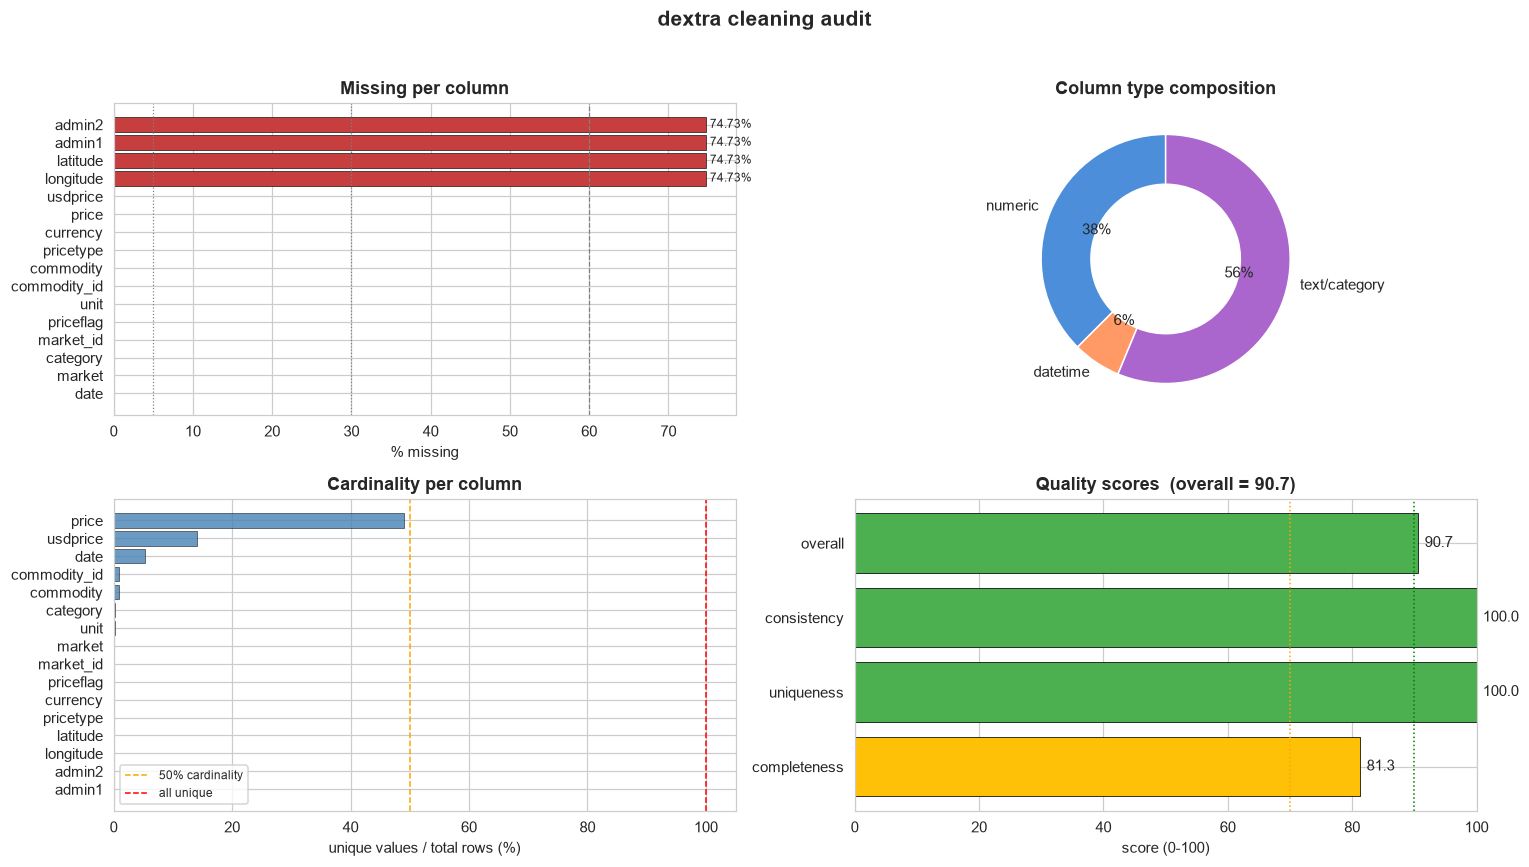

In [6]:
dx.audit(prices)

Missing values report for: prices
---------------------------------


,dtype,n_total,n_missing,pct_missing,sample_value,recommendation
column,,,,,,
date,datetime64[us],"3,490",0,0.00%,2010-08-15 00:00:00,OK
admin1,object,"3,490","2,608",74.73%,Cairo,drop_column
admin2,object,"3,490","2,608",74.73%,Abdin,drop_column
market,object,"3,490",0,0.00%,National Average,OK
market_id,int64,"3,490",0,0.00%,226.00,OK
latitude,float64,"3,490","2,608",74.73%,30.05,drop_column
longitude,float64,"3,490","2,608",74.73%,31.24,drop_column
category,object,"3,490",0,0.00%,cereals and tubers,OK
commodity,object,"3,490",0,0.00%,Pasta,OK



Decision: 10432 missing cell(s) across 4/16 column(s).  882 of 3,490 rows are complete (25.27%).



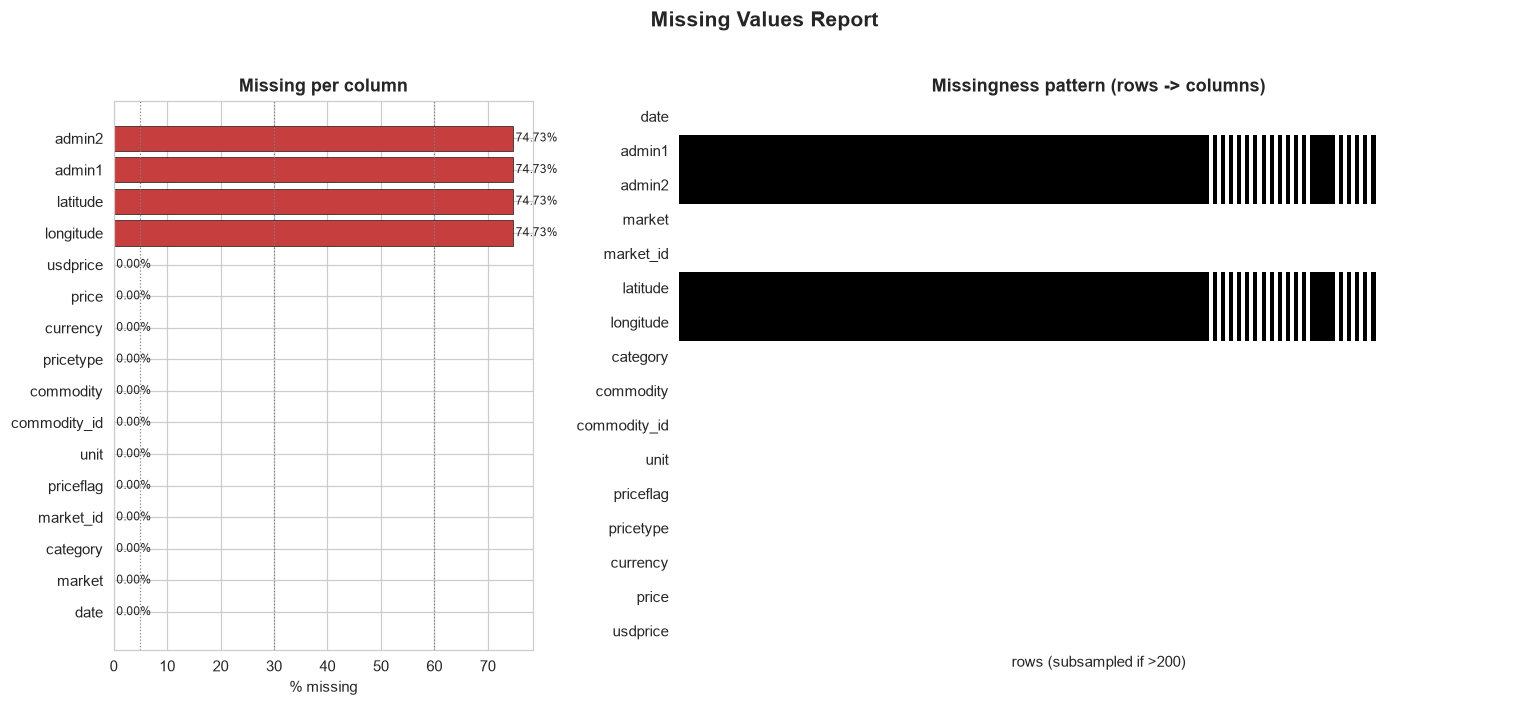

In [7]:
dx.missing_report(prices)

### خريطة الفقدان تقول: هذا نمط، لا صدفة

الأعمدة الأربعة الناقصة ناقصة **معاً وبنفس النسبة تماماً** — 2,608 صفاً
بلا محافظة ولا مديرية ولا إحداثيات. الفقدان العشوائي لا يصطف هكذا؛
الفقدان البنيوي يفعل. سنكشف السبب في الفخ الأول بعد قليل.

In [8]:
dx.dupscan(prices)

Duplicate inspection for: prices
--------------------------------

Decision: No duplicate rows found.



Rule validation for: prices  (5 rule(s))
----------------------------------------


,severity,n_violations,pct_violations,status,description
rule,,,,,
price_positive,error,0,0.00%,PASS,
usd_positive,error,0,0.00%,PASS,
one_currency,error,0,0.00%,PASS,عملة واحدة في الملف كله
retail_only,error,0,0.00%,PASS,أسعار تجزئة فقط -- لا خلط مع الجملة
one_unit_per_commodity,error,0,0.00%,PASS,لكل سلعة وحدة قياس واحدة ثابتة عبر الملف



Decision: 5 PASS, 0 FAIL, 0 ERROR out of 5 rule(s).  0 row(s) violate at least one rule.



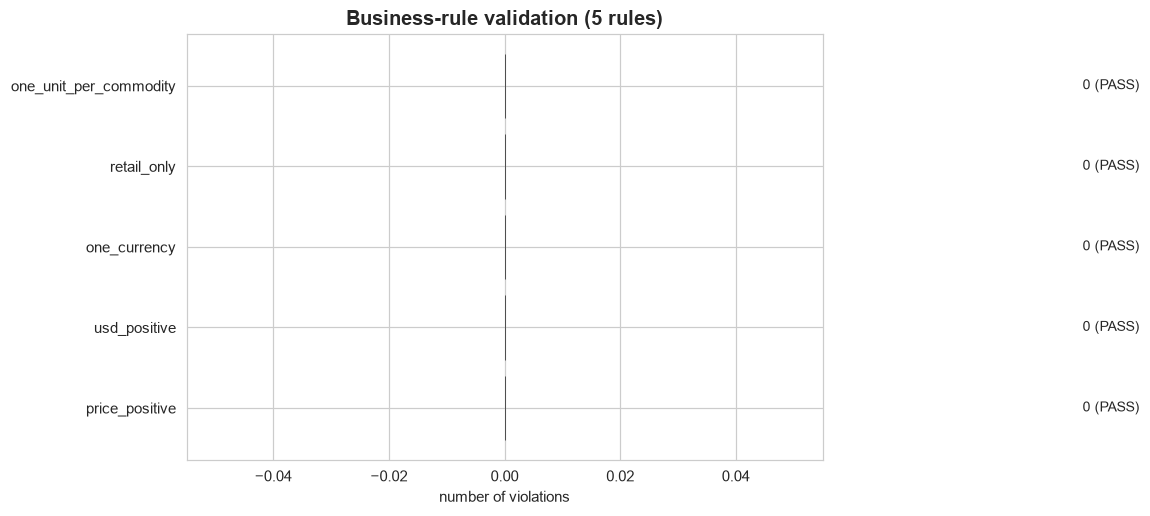

In [9]:
rules = [
    {"name": "price_positive", "check": "price > 0"},
    {"name": "usd_positive",   "check": "usdprice > 0"},
    {"name": "one_currency",   "check": "currency == 'EGP'",
     "description": "عملة واحدة في الملف كله"},
    {"name": "retail_only",    "check": "pricetype == 'Retail'",
     "description": "أسعار تجزئة فقط -- لا خلط مع الجملة"},
    {"name": "one_unit_per_commodity",
     "check": lambda d: d.groupby("commodity")["unit"].transform("nunique") == 1,
     "description": "لكل سلعة وحدة قياس واحدة ثابتة عبر الملف"},
]
dx.validate_rules(prices, rules)

### لوحة خضراء — والنظافة التقنية ليست جاهزية تحليلية

خمس قواعد، خمسة اجتيازات، صفر مخالفة: لا أسعار سالبة، عملة واحدة، تجزئة
فقط، ولكل سلعة وحدة قياس ثابتة (فلا نحتاج توحيد وحدات داخل السلعة الواحدة
— وإن بقيت المقارنة *بين* السلع مشروطة بوحداتها: كيلو الأرز لا يقارن
بلتر الحليب إلا بالنسب لا بالمستويات).

هذه البيانات «نظيفة تقنياً». لكن الفخّين الحقيقيين لا تراهما قاعدة آلية،
لأنهما **بنيويان** — وهذا موضوعنا الآن.

## الفخ الأول: حُبيبية مختلطة في عمود واحد

عمود `market` يبدو بريئاً. لنعدّ قيمه.

Frequency table for: prices[market]
-----------------------------------


,count,pct,cumulative_count,cumulative_pct
market,,,,
National Average,"2,608",74.73%,"2,608",74.73%
Cairo (national average),882,25.27%,"3,490",100.00%



Decision: 2 unique value(s).  Top category 'National Average' covers 74.73%.  Missing: 0.



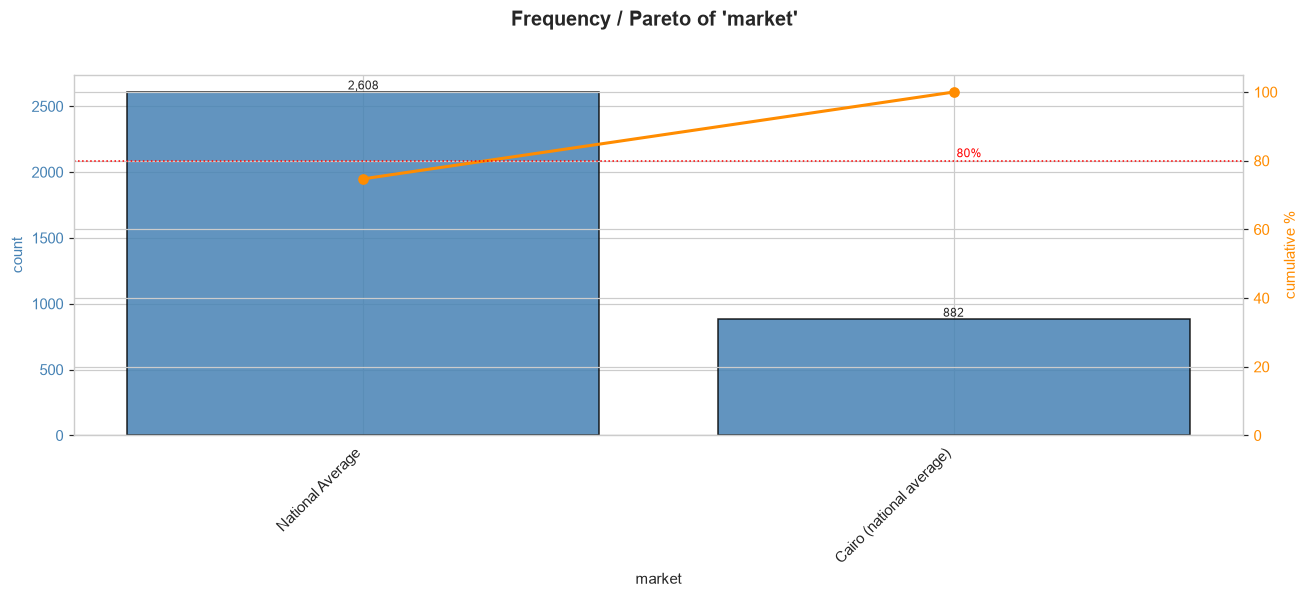

In [10]:
dx.frequency_table(prices, "market")

In [11]:
nat = prices[prices["market"] == "National Average"].copy()
cai = prices[prices["market"] == "Cairo (national average)"].copy()
for name, part in [("National Average", nat), ("Cairo (nat. avg)", cai)]:
    print(f"{name:22s} {len(part):5,} صف | {part.date.min():%Y-%m} → {part.date.max():%Y-%m}"
          f" | {part.commodity.nunique():2d} سلعة")

National Average       2,608 صف | 2010-08 → 2022-10 | 24 سلعة
Cairo (nat. avg)         882 صف | 2021-01 → 2026-03 | 14 سلعة


### الاكتشاف المزدوج

من 68 سوقاً في الدليل، **سوقان فقط** يحملان أسعاراً — وكلاهما ليس سوقاً
حقيقياً بل «متوسط» محسوب: متوسط وطني، ومتوسط للقاهرة. من حسب «متوسط
السعر في مصر» عبر الملف كله لخلط متوسطين بحُبيبيتين مختلفتين.

والأخطر: **السلسلة الوطنية تتوقف في أكتوبر 2022، وسلسلة القاهرة تبدأ في
يناير 2021** — انقطاع منهجية حقيقي مع 22 شهر تداخل. وهنا يتفسر الفقدان
البنيوي: صفوف المتوسط الوطني بلا محافظة ولا إحداثيات **بالتعريف** — لا
جغرافيا لمتوسط وطني. من «عوّض» هذه الفراغات بـ`handle_missing` ارتكب خطأ
منطقياً لا إحصائياً (وتذكّر من الدفتر الثاني: دليل dextra نفسه يصف خطوات
التنظيف هذه بأنها "leakage-prone" — أدوات قوية، شرطها فهم ما تفعل).

## الفخ الثاني: أنوصل السلسلتين؟ الاختبار يقرر

إغراء الدمج قوي: سلسلة تنتهي وأخرى تبدأ، فلنلصقهما ونحصل على 15 سنة متصلة.
لكن «متوسط القاهرة» ليس «المتوسط الوطني» — فهل يختلفان فعلاً؟

عندنا فترة تداخل (يناير 2021 → أكتوبر 2022) وسبع سلع مشتركة بالاسم الحرفي
— أزواج قياس مثالية لاختبار ت المزدوج: نفس السلعة، نفس الشهر، مصدران.

(لاحظ إفصاحاً صغيراً: بعض السلع *غيّرت اسمها* بين السلسلتين —
`Wheat flour` صارت `Wheat flour (unpacked, 72%)` — فلا تدخل المقارنة
الحرفية أصلاً. إعادة تسمية الأصناف بين المنهجيات خبث بيانات كلاسيكي.)

In [12]:
nat["ym"] = nat["date"].dt.to_period("M")
cai["ym"] = cai["date"].dt.to_period("M")
common = sorted(set(nat["commodity"]) & set(cai["commodity"]))
pairs = (nat[nat["commodity"].isin(common)][["ym", "commodity", "price"]]
         .merge(cai[cai["commodity"].isin(common)][["ym", "commodity", "price"]],
                on=["ym", "commodity"], suffixes=("_nat", "_cai")))
print("سلع مشتركة بالاسم الحرفي:", len(common), "|", ", ".join(common))
print("أزواج (شهر، سلعة):", len(pairs),
      "| التداخل:", pairs.ym.min(), "→", pairs.ym.max())

سلع مشتركة بالاسم الحرفي: 7 | Beans (fava, dry), Fish (tilapia), Lentils, Pasta, Rice, Sugar, Tomatoes
أزواج (شهر، سلعة): 132 | التداخل: 2021-01 → 2022-10


Paired t-test: Cairo vs National  (alt = two-sided, alpha = 0.05)
-----------------------------------------------------------------


,value
metric,
n_pairs,132.0000
mean_National,14.7765
mean_Cairo,15.2223
mean_diff (Cairo - National),0.4458
std_diff,2.0044
SE_diff,0.1745
t_statistic,2.5555
df,131.0000
p_value,0.0117



Decision: Reject H0 (p = 0.0117 < 0.05).  Mean change = +0.4458, Cohen's d = +0.2224.



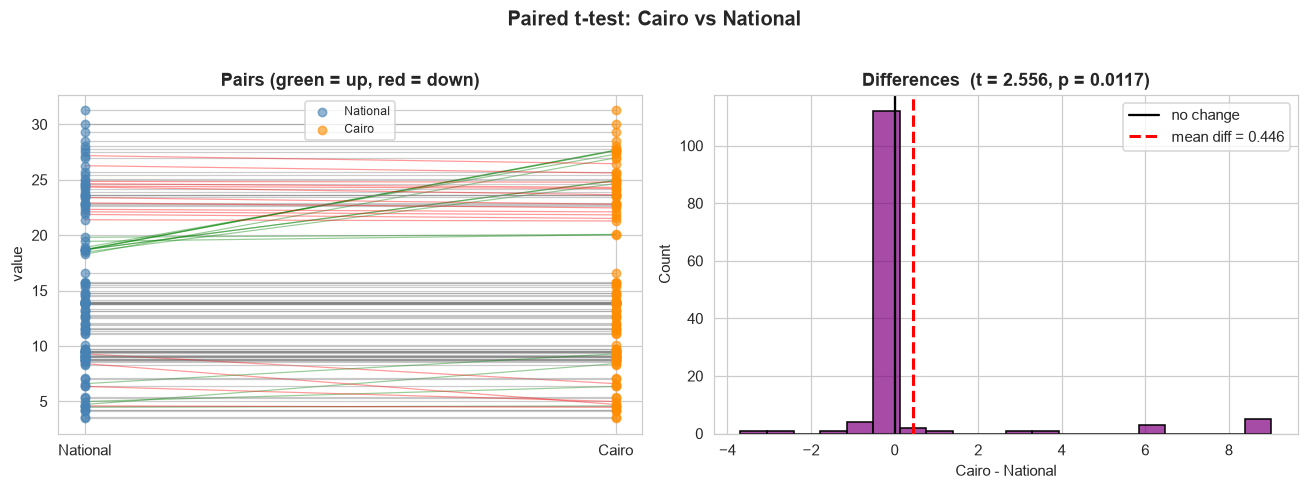

In [13]:
dx.t_test_paired(pairs["price_nat"], pairs["price_cai"],
                 name_before="National", name_after="Cairo")

### القرار الموثق: لا دمج للأسعار

الاختبار يرفض فرضية التطابق (اقرأ p-value في البطاقة أعلاه): أسعار
القاهرة أعلى منهجياً من المتوسط الوطني في نفس الشهور لنفس السلع. القرار:

- **لا نلصق سلسلتي الأسعار** — كل تحليل مستويات يُجرى داخل سلسلة واحدة.
- عند العرض الزمني الطويل نرسم السلسلتين بلونين وفاصل مُعلن.
- القرار مبني على اختبار مطبوع أعلاه، لا على ذوق المحلل — وهذا قابل
  للمراجعة والاعتراض، وهو المطلوب.

## قصة الجنيه: سعر الصرف الضمني

في كل صف سعران: `price` بالجنيه و`usdprice` بالدولار. قسمتهما تعطينا
**سعر التحويل الذي استخدمه المصدر** في ذلك الشهر — سلسلة سعر صرف ضمنية
مجانية داخل بيانات الغذاء.

وسؤال العبور: هل تختلف هذه النسبة بين السلسلتين؟ لا ينبغي — التحويل خاصية
الشهر لا السوق. نتحقق قبل أن نصل السلسلة عبر الانقطاع.

In [14]:
prices["rate"] = prices["price"] / prices["usdprice"]
prices["ym"] = prices["date"].dt.to_period("M")

by_series = prices.groupby(["ym", "market"])["rate"].mean().unstack()
overlap = by_series.dropna()
rel_gap = ((overlap.iloc[:, 0] - overlap.iloc[:, 1]).abs() / overlap.iloc[:, 0])
print(f"شهور فيها السلسلتان معاً: {len(overlap)}"
      f" | أقصى فرق نسبي بين سعري الصرف: {rel_gap.max():.2%}")

within = prices.groupby(["ym", "market"])["rate"].agg(["min", "max"])
spread = (within["max"] - within["min"]) / within["min"]
print(f"تشتت السعر الضمني داخل الشهر الواحد: الوسيط {spread.median():.1%}")

rate_m = prices.groupby("ym")["rate"].mean()
print(f"المدى: {rate_m.iloc[0]:.2f} ({rate_m.index[0]}) → "
      f"{rate_m.iloc[-1]:.2f} ({rate_m.index[-1]})")

شهور فيها السلسلتان معاً: 22 | أقصى فرق نسبي بين سعري الصرف: 0.27%
تشتت السعر الضمني داخل الشهر الواحد: الوسيط 2.4%
المدى: 5.69 (2010-08) → 52.55 (2026-03)


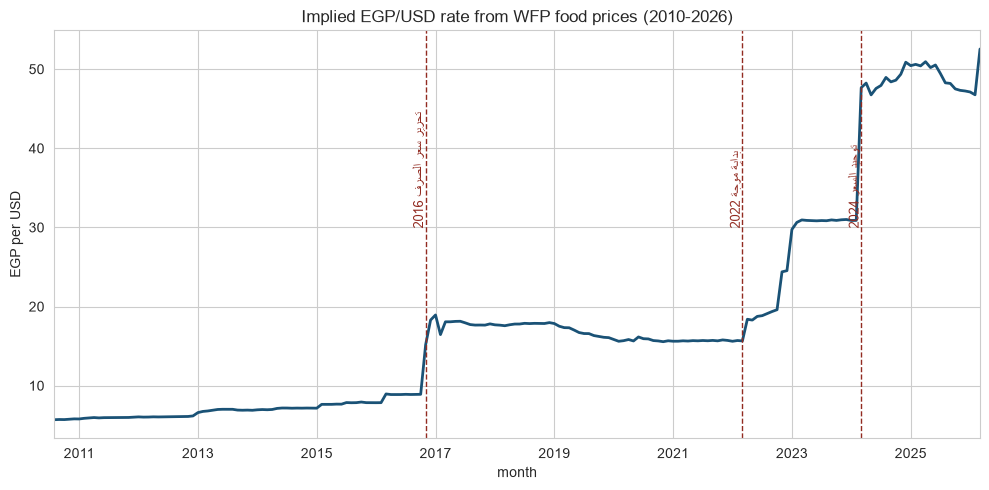

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
rate_m.plot(ax=ax, lw=2, color="#1a5276")
events = {"2016-11": "تحرير سعر الصرف 2016", "2022-03": "بداية موجة 2022",
          "2024-03": "توحيد السعر 2024"}
for ym, label in events.items():
    x = pd.Period(ym, freq="M")
    ax.axvline(x.ordinal, ls="--", lw=1, color="#922b21")
    ax.annotate(label, (x.ordinal, ax.get_ylim()[1]*0.55),
                rotation=90, fontsize=9, ha="right", color="#922b21")
ax.set_title("Implied EGP/USD rate from WFP food prices (2010-2026)")
ax.set_xlabel("month"); ax.set_ylabel("EGP per USD")
plt.tight_layout(); plt.show()

### القراءة

الفرق بين سعرَي صرف السلسلتين في شهور التداخل أقل من 1% — إذن **سعر الصرف
الضمني يعبر الانقطاع بأمان** بينما الأسعار نفسها لا تعبر. هذه هي الدقة التي
نريدها: نفس الجدول، عمود يجوز وصله وعمود لا يجوز.

الرحلة الكاملة من ~5.7 جنيه للدولار (2010) إلى ما فوق 50 (2024 فصاعداً)،
والقفزات الثلاث المعلمة على الرسم تطابق أحداثاً نقدية معروفة تاريخياً.

**إفصاح**: هذا سعر *ضمني* مشتق من أسعار مقربة — تشتته داخل الشهر الواحد
وسيطه ~2.4% — فهو ممتاز لرواية الاتجاه والقفزات، وليس بديلاً عن سلاسل
البنك المركزي للأغراض الدقيقة.

## التضخم بالرقم القياسي — بالجنيه ثم بالدولار

قاعدتان للمقارنة العادلة قبل أي رسم:

1. **تغطية متساوية**: نقارن فقط السلع الحاضرة في كل شهور السلسلة الوطنية
   (145 شهراً). مقارنة سلعة عاشت 145 شهراً بأخرى سُجلت 3 شهور كذبة بصرية.
2. **فترة أساس ممتدة**: الأساس = متوسط أول 12 شهراً (100=)، لا شهر واحد —
   الشهر الواحد يورّث ضجيجه للمؤشر كله.

In [16]:
cov = nat.groupby("commodity")["date"].nunique()
basket = sorted(cov[cov == cov.max()].index)
print(f"سلة المقارنة: {len(basket)} سلع بتغطية كاملة ({cov.max()} شهراً)")
print(", ".join(basket))

pv_egp = nat[nat.commodity.isin(basket)].pivot_table(
    index="date", columns="commodity", values="price")
idx_egp = pv_egp / pv_egp.iloc[:12].mean() * 100

pv_usd = nat[nat.commodity.isin(basket)].pivot_table(
    index="date", columns="commodity", values="usdprice")
idx_usd = pv_usd / pv_usd.iloc[:12].mean() * 100

سلة المقارنة: 10 سلع بتغطية كاملة (145 شهراً)
Beans (fava, dry), Garlic, Ghee (natural), Lentils, Meat (chicken, frozen), Pasta, Potatoes, Sugar, Tomatoes, Wheat flour


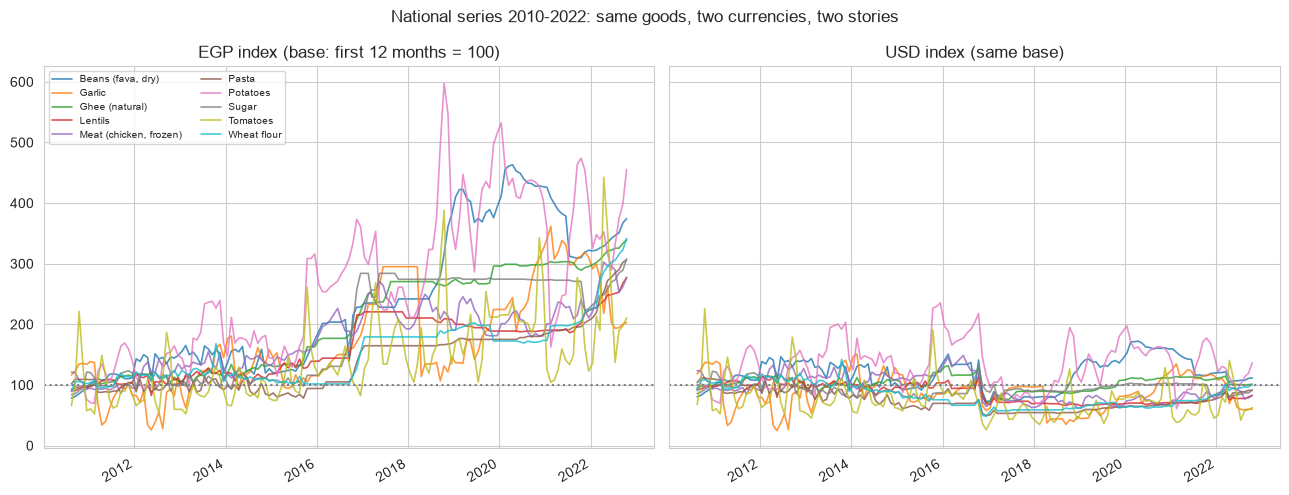

                        EGP_index  USD_index
commodity                                   
Potatoes                    455.0      137.0
Beans (fava, dry)           374.0      112.0
Wheat flour                 342.0      101.0
Ghee (natural)              339.0      101.0
Sugar                       308.0       92.0
Pasta                       306.0       91.0
Meat (chicken, frozen)      278.0       83.0
Lentils                     277.0       83.0
Tomatoes                    211.0       63.0
Garlic                      203.0       60.0


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, idx, ttl in [(axes[0], idx_egp, "EGP index (base: first 12 months = 100)"),
                     (axes[1], idx_usd, "USD index (same base)")]:
    idx.plot(ax=ax, legend=False, lw=1.2, alpha=0.8)
    ax.axhline(100, ls=":", color="grey")
    ax.set_title(ttl); ax.set_xlabel("")
axes[0].legend(fontsize=7, ncol=2)
plt.suptitle("National series 2010-2022: same goods, two currencies, two stories")
plt.tight_layout(); plt.show()

final = pd.DataFrame({"EGP_index": idx_egp.iloc[-1], "USD_index": idx_usd.iloc[-1]}
                    ).round(0).sort_values("EGP_index", ascending=False)
print(final.to_string())

### القصة في عمودين

اقرأ الجدول أعلاه سطراً سطراً: البطاطس عند نهاية السلسلة الوطنية
(أكتوبر 2022) على مؤشر 455 بالجنيه مقابل **137 فقط بالدولار**؛ السكر 308
مقابل 92؛ الطماطم 211 مقابل 63. بالدولار، بعض السلع أرخص مما كانت في سنة
الأساس — **قسم كبير من «الغلاء» بالجنيه هو قصة عملة قبل أن يكون قصة
غذاء**. هذا لا يخفف أثره على من يقبض بالجنيه — لكنه يشخّص السبب،
والتشخيص شرط العلاج.

(حالة الثوم لافتة: أساسه 2010-2011 كان مرتفعاً أصلاً — أزمة ثوم معروفة —
فمؤشره يبدو «هادئاً» رغم تقلبه العنيف. اختيار فترة الأساس ليس تفصيلاً.)

In [18]:
# موجة 2021-2026 من سلسلة القاهرة -- بأساسها الخاص (لا وصل بالمستويات)
pv_cai = cai.pivot_table(index="date", columns="commodity", values="price")
full_cai = pv_cai.columns[pv_cai.notna().all()]
idx_cai = pv_cai[full_cai] / pv_cai[full_cai].iloc[:12].mean() * 100
last = idx_cai.iloc[-1].sort_values(ascending=False)
print("سلسلة القاهرة (الأساس: 2021 = 100) — قيم", idx_cai.index[-1].strftime("%Y-%m"), ":")
print(last.round(0).to_string())

سلسلة القاهرة (الأساس: 2021 = 100) — قيم 2026-03 :
commodity
Tomatoes                            500.0
Sugar                               452.0
Cheese (local, processed, Nesto)    408.0
Cucumbers (medium sized)            395.0
Meat (chicken, farm)                366.0
Pasta                               324.0
Fish (tilapia)                      320.0
Rice                                312.0
Eggs (medium size)                  311.0
Wheat flour (unpacked, 72%)         293.0
Oil (cotton)                        280.0
Lentils                             260.0
Milk (fresh)                        240.0
Beans (fava, dry)                   219.0


موجة 2022–2024 في سلسلة القاهرة أعنف من كل ما قبلها: الطماطم على مؤشر
500 والسكر 452 **في نحو خمس سنوات فقط** (أساس 2021) — أي أن سلعاً أساسية
راكمت في خمس سنوات ما لم تراكمه قمة السلسلة الوطنية (بطاطس 455) في اثنتي
عشرة سنة.
الأرقام أعلاه بأساس 2021=100 — تذكّر أنها **لا تُقارن مستوياتها** بمؤشر
السلسلة الوطنية (أساس مختلف، منهجية مختلفة؛ هذا هو الإفصاح الذي فرضه
اختبارنا المزدوج).

## السلاسل الزمنية بأدوات dextra: سكون وتفكيك

ملحق `[ts]` في dextra يجلب أدوات السلاسل. نطبقها على دقيق القمح — سلعة
الخبز، أسياسية السلع — في السلسلة الوطنية (145 شهراً):

- `tsstat`: هل السلسلة ساكنة؟ (اختبارا ADF وKPSS معاً — والصادق يطلبهما
  معاً لأن كلاً منهما يخطئ وحده)
- `tsdecomp`: كم من الحركة اتجاه، وكم موسمية؟

Stationarity for: wheat  (value=price, mode=series)
---------------------------------------------------


,statistic,p_value,null_hypothesis,reject_null,implies_stationary
ADF,1.7659,0.9983,unit root (non-stationary),False,False
KPSS,1.3679,0.0100,stationary,True,False



Decision: 145 obs: ADF p=0.9983 (unit root), KPSS p=0.0100 (non-stationary) -> non-stationary (unit root) -> difference; suggested d=1 (mode=series).



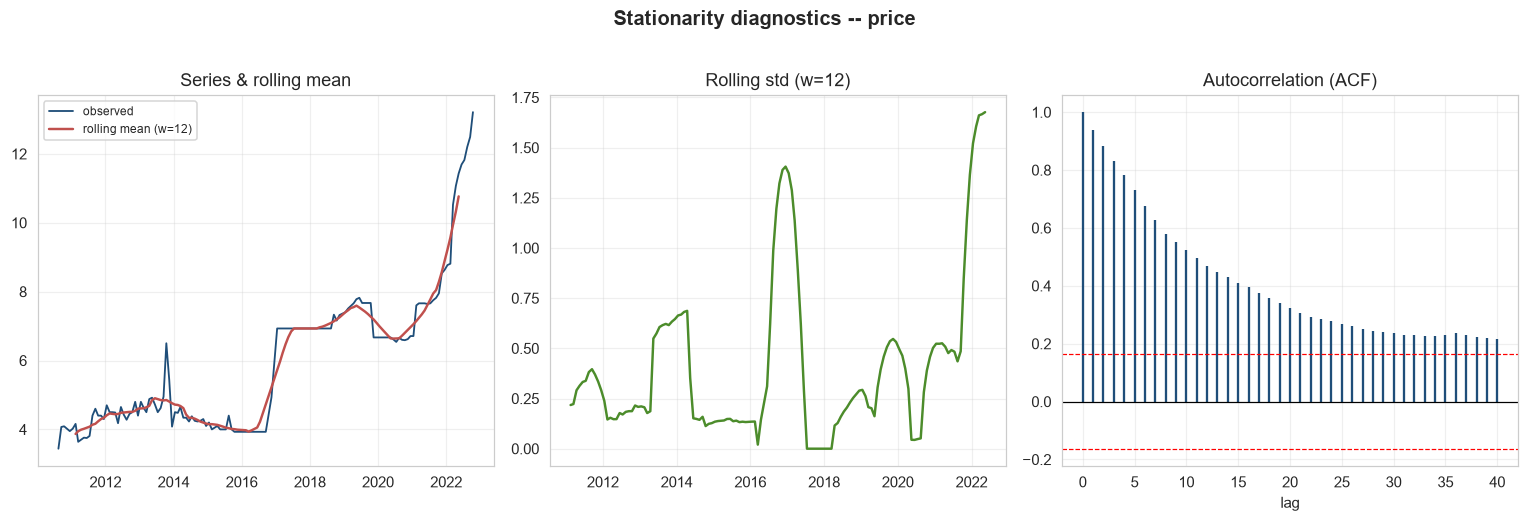

,statistic,p_value,null_hypothesis,reject_null,implies_stationary
ADF,1.765858,0.998279,unit root (non-stationary),False,False
KPSS,1.367945,0.010000,stationary,True,False


In [19]:
wheat = (nat[nat["commodity"] == "Wheat flour"]
         [["date", "price"]].sort_values("date"))
dx.tsstat(wheat, value="price", time="date")

Decomposition for: wheat  (value=price, mode=series)
----------------------------------------------------


,value
period,12
model,additive
method,classical
strength_trend,0.9625
strength_seasonal,0.0799
resid_std,0.3150
n_obs,145



Decision: 145 obs, period=12, additive (classical): trend strength=0.9625, seasonal strength=0.0799, residual std=0.3150 (mode=series).



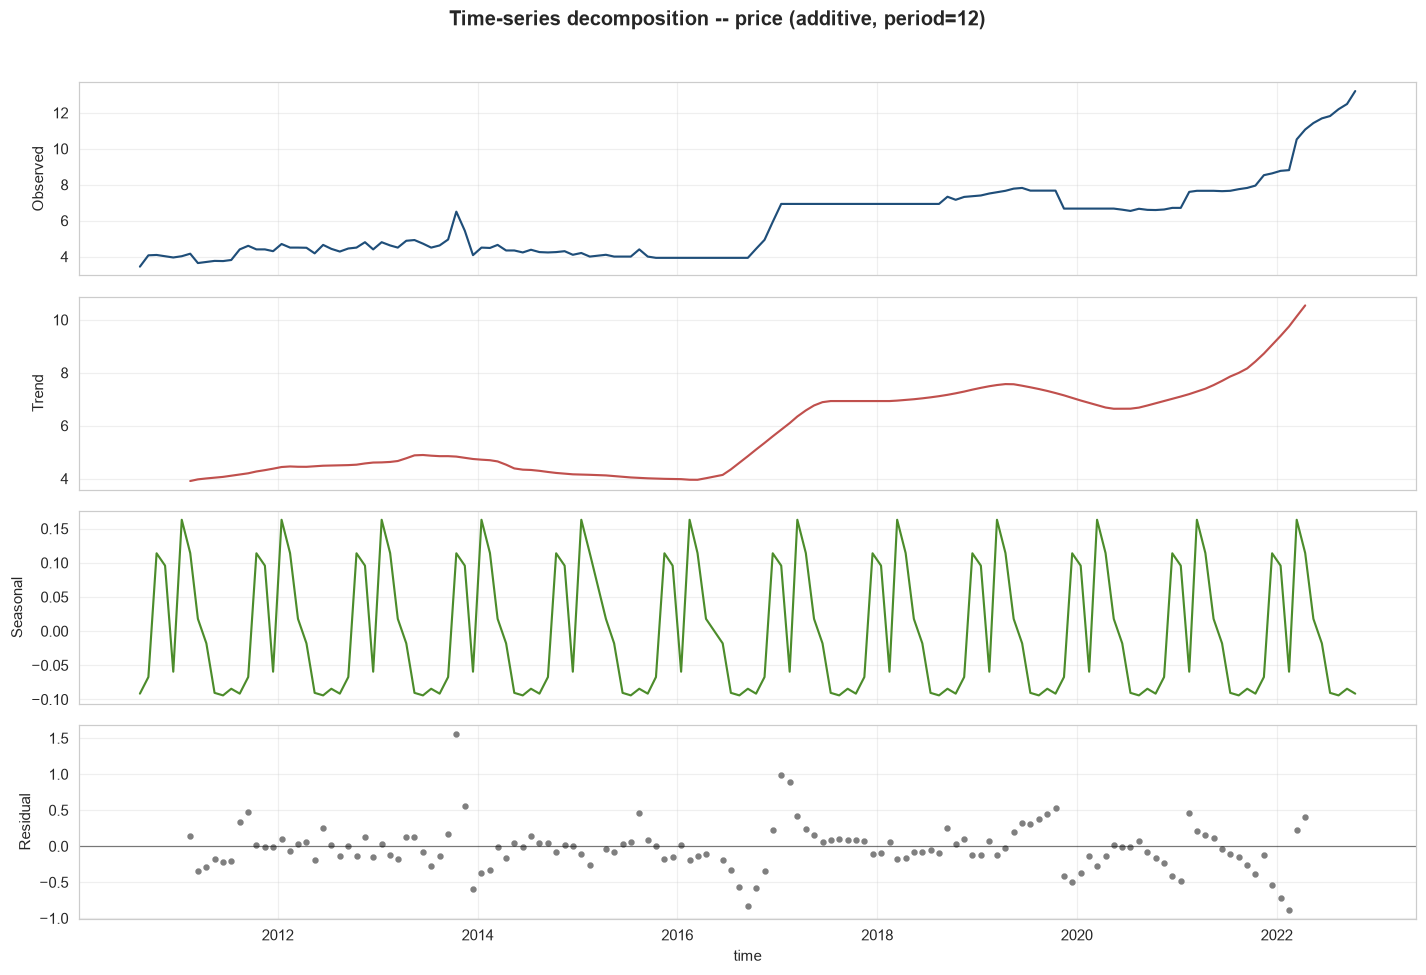

,observed,trend,seasonal,resid
date,,,,
2010-08-15,3.44,NaN,-0.091534,NaN
2010-09-15,4.07,NaN,-0.067216,NaN
2010-10-15,4.09,NaN,0.113920,NaN
2010-11-15,4.02,NaN,0.095852,NaN
2010-12-15,3.95,NaN,-0.059413,NaN
...,...,...,...,...
2022-06-15,11.69,NaN,-0.017936,NaN
2022-07-15,11.82,NaN,-0.090398,NaN
2022-08-15,12.20,NaN,-0.094072,NaN


In [20]:
dx.tsdecomp(wheat, value="price", time="date", period=12)

### القراءة: تضخمُ اتجاهٍ لا مواسم

الاختباران متفقان: السلسلة غير ساكنة وتحتاج فرقاً أول (d=1) — طبيعي تماماً
لسلسلة أسعار اسمية في اقتصاد متضخم. والتفكيك يحسمها كمّياً: قوة الاتجاه
~0.96 مقابل موسمية ~0.08 — **حركة دقيق القمح كلها اتجاه صاعد تقريباً، ولا
موسم زراعياً يذكر في التجزئة** (الدعم والتخزين يمتصان الموسمية قبل
المستهلك). من أراد نمذجة هذه السلسلة فليشتغل على الفروق لا المستويات.

## الشواذ الصادقة: من يصرخ في البيانات فعلاً؟

سننظر في **التغير الشهري %** لا في المستويات (المستوى الصاعد يجعل كل
الأسعار الحديثة «شاذة» زوراً). ثم نسأل سؤالين منفصلين:

1. ماذا تقول قاعدة IQR الميكانيكية عن تغيرات دقيق القمح؟
2. ما أكبر القفزات الشهرية عبر كل السلع — وهل هي أخطاء تستحق الحذف؟

Outliers report for: wheat_chg  (method=iqr, k=1.5)
---------------------------------------------------


,method,n_valid,n_outliers,pct_outliers,q1,q3,iqr,lower_bound,upper_bound
column,,,,,,,,,
pct_change,iqr,144,40,27.78%,-0.04,1.69,1.73,-2.63,4.28



Decision: 40 row(s) (27.78%) are outlying in at least one column.



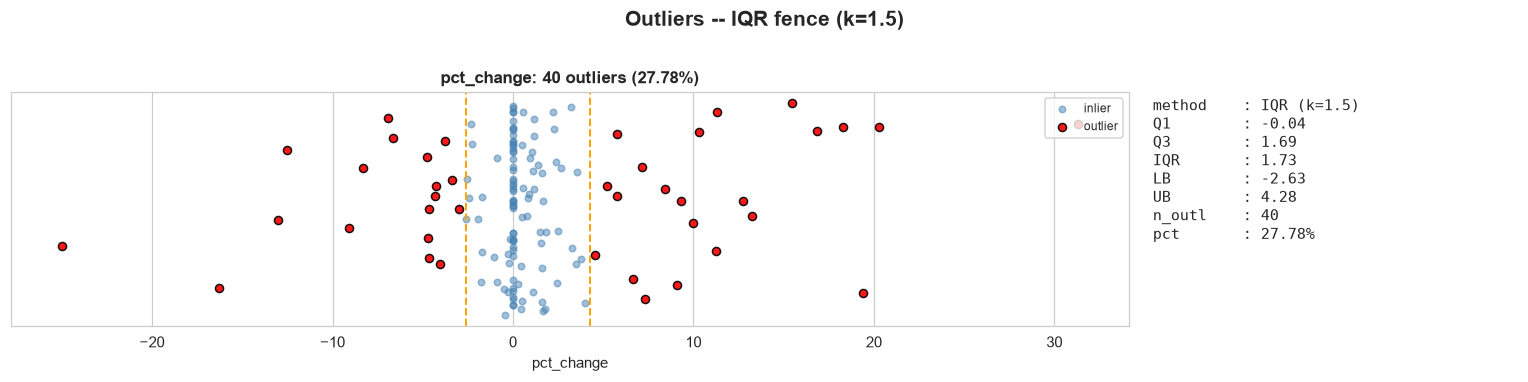

In [21]:
wheat_chg = (wheat.set_index("date")["price"].pct_change()
             .mul(100).dropna().rename("pct_change").to_frame())
dx.outliers_report(wheat_chg, method="iqr")

In [22]:
pv_all = nat.pivot_table(index="date", columns="commodity", values="price")
# تغير شهري صريح بلا حشو للفجوات -- الحشو يصنع "تغيراً شهرياً" زائفاً
chg_all = pv_all.div(pv_all.shift(1)).sub(1).mul(100)
top_spikes = chg_all.stack().sort_values(ascending=False).head(8)
top_spikes = top_spikes.reset_index()
top_spikes.columns = ["month", "commodity", "jump_pct"]
top_spikes["month"] = top_spikes["month"].dt.strftime("%Y-%m")
print(top_spikes.round(1).to_string(index=False))

  month commodity  jump_pct
2012-09    Garlic     214.8
2022-04  Tomatoes     133.4
2012-08  Tomatoes     109.5
2010-10  Tomatoes     108.1
2011-03  Tomatoes     101.1
2018-09  Tomatoes      86.4
2021-09  Tomatoes      86.2
2013-04  Potatoes      85.4


### المفارقة المزدوجة

**الأولى**: قاعدة IQR «تتهم» نحو ربع شهور دقيق القمح بالشذوذ (اقرأ النسبة
في البطاقة أعلاه). قاعدة مبنية على افتراض توزيع مستقر تنهار حين تكون
السلسلة نفسها مليئة بصدمات بنيوية — الشاذ هنا ليس خطأ قياس بل **طبيعة
المسار**. من حذف «الشواذ» آلياً هنا حذف التاريخ النقدي المصري من بياناته.

**الثانية**: جدول أكبر القفزات لا يتصدره التعويم ولا أي حدث نقدي — بل
**الثوم والطماطم**: صدمات عرض موسمية للخضر الطازجة (+215% للثوم في شهر
واحد عام 2012، وقفزات طماطم متكررة عبر السنين). التعويم يسكن في *الاتجاه
والمستوى* كما رأينا في التفكيك، والخضروات تملك *القفزة الشهرية*. *أين
تنظر يحدد ماذا ترى* — وكلا المكانين صادق، لكن لسؤالين مختلفين.

(صدى الدفتر الأول: أكبر «مرتجع» هناك كان حادث إدخال واحداً — التحقق قبل
الحذف، دائماً. هنا التحقق أثبت العكس: القفزات حقيقية فتبقى.)

## التقرير الشامل بسطر واحد

`edareport` يبني تقرير HTML كاملاً (توزيعات، فقدان، ارتباطات، فئات) يصلح
مرفقاً لبريد أو اجتماعاً — نستثني الأعمدة الثابتة والمعرّفات لأنها ضجيج
في تقرير استكشافي.

In [23]:
import os
report_df = prices.drop(columns=[
    "currency", "pricetype", "priceflag",      # ثوابت -- لا معلومة فيها
    "market_id", "commodity_id",               # معرفات
    "admin1", "admin2", "latitude", "longitude",  # جغرافيا شبه فارغة/ثابتة
    "ym"])
dx.edareport(report_df, out="egypt_food_prices_report.html",
             title="Egypt Food Prices -- WFP/HDX (CC BY-IGO)")
print(f"حجم التقرير: {os.path.getsize('egypt_food_prices_report.html')/1e6:.2f} MB")

,dtype,n_total,n_missing,pct_missing,sample_value,recommendation
column,,,,,,
date,datetime64[us],"3,490",0,0.00%,2010-08-15 00:00:00,OK
market,object,"3,490",0,0.00%,National Average,OK
category,object,"3,490",0,0.00%,cereals and tubers,OK
commodity,object,"3,490",0,0.00%,Pasta,OK
unit,object,"3,490",0,0.00%,KG,OK
price,float64,"3,490",0,0.00%,4.70,OK
usdprice,float64,"3,490",0,0.00%,0.82,OK
rate,float64,"3,490",0,0.00%,5.73,OK


,method,n_valid,n_outliers,pct_outliers,q1,q3,iqr,lower_bound,upper_bound
column,,,,,,,,,
price,iqr,"3,490",283,8.11%,6.25,28.00,21.75,-26.37,60.62
usdprice,iqr,"3,490",292,8.37%,0.51,1.70,1.19,-1.27,3.48
rate,iqr,"3,490",350,10.03%,7.21,18.11,10.91,-9.16,34.48


,price,usdprice,rate
mean,23.14,1.55,17.41
std,27.67,1.97,12.25
var,765.70,3.87,150.10
cv_%,119.60,126.67,70.37
min,0.66,0.06,5.64
q1,6.25,0.51,7.21
median,13.38,0.89,15.71
diff_mean_median_%,72.92,74.43,10.81
q3,28.00,1.70,18.11
max,172.37,11.67,53.02


,count,pct,cumulative_count,cumulative_pct
date,,,,
2021-01-15,33,0.95%,33,0.95%
2021-02-15,33,0.95%,66,1.89%
2021-03-15,33,0.95%,99,2.84%
2021-04-15,33,0.95%,132,3.78%
2021-05-15,33,0.95%,165,4.73%
...,...,...,...,...
2025-11-15,14,0.40%,"3,434",98.40%
2025-12-15,14,0.40%,"3,448",98.80%
2026-01-15,14,0.40%,"3,462",99.20%


,count,pct,cumulative_count,cumulative_pct
market,,,,
National Average,"2,608",74.73%,"2,608",74.73%
Cairo (national average),882,25.27%,"3,490",100.00%


...

,count,pct,cumulative_count,cumulative_pct
commodity,,,,
Pasta,208,5.96%,208,5.96%
Sugar,208,5.96%,416,11.92%
"Beans (fava, dry)",208,5.96%,624,17.88%
Lentils,208,5.96%,832,23.84%
Tomatoes,208,5.96%,"1,040",29.80%
Rice,207,5.93%,"1,247",35.73%
Potatoes,145,4.15%,"1,392",39.89%
Wheat flour,145,4.15%,"1,537",44.04%
"Meat (chicken, frozen)",145,4.15%,"1,682",48.19%


,count,pct,cumulative_count,cumulative_pct
unit,,,,
KG,"2,785",79.80%,"2,785",79.80%
800 G,376,10.77%,"3,161",90.57%
8 pcs,147,4.21%,"3,308",94.79%
Unit,116,3.32%,"3,424",98.11%
1 piece,63,1.81%,"3,487",99.91%
L,3,0.09%,"3,490",100.00%


,price,usdprice,rate
price,+1.00,+0.78***,+0.31***
usdprice,+0.78***,+1.00,-0.16***
rate,+0.31***,-0.16***,+1.00


,var1,var2,r,p_value,n
0,price,usdprice,+0.78,0.0000,3490
1,price,rate,+0.31,0.0000,3490
2,usdprice,rate,-0.16,0.0000,3490


Decision: Report written to 'egypt_food_prices_report.html': 4 section(s) built.
حجم التقرير: 1.41 MB


## القرارات الموثقة

كل قرار أدناه يقف على رقم مطبوع أعلاه في هذا الدفتر — لا على انطباع:

1. **لا متوسطات عبر الملف كله**: عمود `market` يخفي سلسلتين مختلفتي
   الحُبيبية؛ كل تحليل مستويات داخل سلسلة واحدة.
2. **لا دمج لسلسلتي الأسعار**: اختبار ت المزدوج على 132 زوجاً رفض التطابق
   — القاهرة أعلى منهجياً. الدمج الساذج كان سيبدو «نمواً» زائفاً.
3. **سعر الصرف الضمني يُوصل، الأسعار لا**: فرق السلسلتين فيه أقل من 1% في
   شهور التداخل — عمود يجوز وصله في جدول لا يجوز وصل بقيته.
4. **لا تعويض للفقدان الجغرافي**: 2,608 صفاً بلا جغرافيا لأنها متوسط وطني
   — فقدان بنيوي، تعويضه خطأ منطقي.
5. **مقارنات التضخم على سلة كاملة التغطية وبأساس ممتد** — وبالعملتين معاً:
   جزء كبير من الغلاء بالجنيه قصة عملة.
6. **لا حذف آلياً للشواذ**: قفزات الخضر حقيقية وموسمية، والتعويم يظهر في
   الاتجاه لا في القفزة الشهرية.

**حدود هذه البيانات — بصراحة**: متوسطان محسوبان لا أسواق فردية (فلا تحليل
تباين جغرافي رغم دليل الـ68 سوقاً)، تجزئة فقط، أصناف تتبدل أسماؤها بين
المنهجيات، والسعر الضمني تقريب لا بديل عن سلاسل البنك المركزي.

## الإسناد والروابط وختام الثلاثية

**البيانات**: WFP Food Prices for Egypt عبر
[HDX](https://data.humdata.org/dataset/wfp-food-prices-for-egypt) —
ترخيص **CC BY-IGO** — المصادر الأولية CAPMAS وIDSC. شكراً لمن جمع وفتح
هذه البيانات.

**الروابط**: [توثيق dextra](https://ahmedabdeltawab602-collab.github.io/dextra/) |
[المستودع على GitHub](https://github.com/ahmedabdeltawab602-collab/dextra) |
[pydextra على PyPI](https://pypi.org/project/pydextra/)

**ختام الثلاثية**:

- الدفتر 1 — *من CSV فوضوي إلى قرار*: التنظيف المُفصَح.
- الدفتر 2 — *أنبوب محصّن من التسريب*: التقييم الصادق.
- الدفتر 3 — هذا الدفتر: التحليل الاستكشافي الصادق، بالعربية، على بيانات
  من واقعنا.

نفس الفلسفة في الثلاثة: **كل قرار آلي يُفصَح عنه، وأنت تبقى صاحب القرار.**